# Test Práctico - Científico de Datos SICEX
## Desafío: Unificación y Normalización de Entidades

## Introducción

Este notebook está estructurado para evaluar tus habilidades en el análisis y procesamiento de datos de comercio exterior. Contiene cuatro bloques principales con objetivos claros. Completa cada bloque según las instrucciones. Las tareas avanzadas son opcionales y te permitirán ganar puntos extra.

### CONTEXTO:
SICEX maneja grandes volúmenes de datos de comercio exterior donde uno de los principales 
desafíos es la consistencia y normalización de entidades como nombres de empresas,
ciudades y productos. Este test evaluará tu capacidad para proponer e implementar
soluciones a este problema real.

### OBJETIVOS DE EVALUACIÓN:
- Capacidad de análisis y limpieza de datos
- Habilidad para desarrollar algoritmos de matching y normalización
- Pensamiento creativo en la resolución de problemas
- Capacidad de escalar soluciones
- Documentación y comunicación técnica


In [2]:
# Configuración inicial
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')



In [3]:
from etl_data_science_test import config

In [236]:
import re
import unicodedata
import time
from difflib import SequenceMatcher

In [ ]:
pd.set_option("display.float_format", "{:.0f}".format)

### **Bloque 1: Análisis Exploratorio (EDA)**

#### Objetivo
Familiarízate con el dataset proporcionado y realiza un análisis básico para identificar patrones, inconsistencias y oportunidades de limpieza.


In [4]:
# 1. Cargar datos
def load_and_examine_data():
    # Cargar el dataset
    filepath = os.path.join(config.RAW_DATA_DIR, '10_Importaciones_2024_Octubre.xlsb')
    df = pd.read_excel(filepath)
    
    # Información básica del dataset
    print("=== INFORMACIÓN BÁSICA DEL DATASET ===")
    print(f"Número de registros: {len(df)}")
    print(f"Número de columnas: {len(df.columns)}")
    
    return df

##  EJERCICIO 1: ANÁLISIS EXPLORATORIO Y DIAGNÓSTICO 

Trabajaremos con un dataset real de importaciones que contiene información sobre empresas
y ubicaciones. Tu primera tarea es realizar un análisis exploratorio enfocado en 
la calidad de los datos de las entidades.

### Analiza específicamente:
1. Nombres de empresas (NOMBRE_IMPORTADOR, NOMBRE_EXPORTADOR)
2. Ubicaciones (CIUDAD_PAIS_EXPORTADOR, DEPARTAMENTO_IMPORTADOR)
3. Direcciones (DIRECCION_IMPORTADOR, DIRECCION_EXPORTADOR)

### Para cada campo:
- Identifica patrones en las inconsistencias
- Cuantifica el impacto de estas inconsistencias
- Propón una estrategia de limpieza y normalización


In [191]:
# Funciones auxiliales 

def quitar_tildes(texto):
    if pd.isna(texto):
        return np.nan
    
    texto = str(texto)

    texto = texto.replace("ñ", "__ene_min__")
    texto = texto.replace("Ñ", "__ene_may__")

    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])

    texto = texto.replace("__ene_min__", "ñ")
    texto = texto.replace("__ene_may__", "Ñ")

    return texto


def normalizar_texto(texto):
    """
    Normalización general
    """
    if pd.isna(texto):
        return np.nan
    
    texto = str(texto).strip()

    if texto == "":
        return np.nan

    texto = quitar_tildes(texto)
    texto = texto.upper()
    texto = re.sub(r"\s+", " ", texto)

    return texto

def normalizar_direccion(texto):
    """
    - Convierte a mayúsculas
    - Quita espacios iniciales/finales
    - Reduce espacios múltiples
    - Conserva guiones y caracteres útiles para las direcciones
    - Estandariza espacios alrededor de guiones
    """
    if pd.isna(texto):
        return np.nan
    
    texto = str(texto).strip()

    if texto == "":
        return np.nan

    texto = texto.upper()
    texto = re.sub(r"\s+", " ", texto)

    # Estandariza espacios alrededor del guion
    texto = re.sub(r"\s*-\s*", "-", texto)

    return texto


In [194]:
def analyze_entity_fields(df):
    """
    Normaliza columnas tipo texto de la base.

    - Todas las columnas texto se normalizan con normalizar_texto.
    - DIRECCION_IMPORTADOR y DIRECCION_EXPORTADOR solo se pasan a mayúscula
      y se limpian espacios con normalizar_direccion.
    - No toca columnas numéricas ni fechas.
    """

    df_normalizado = df.copy()

    columnas_texto = df.select_dtypes(include=["object", "string"]).columns.tolist()

    columnas_direccion = [
        "DIRECCION_IMPORTADOR",
        "DIRECCION_EXPORTADOR"
    ]

    columnas_direccion_existentes = [
        col for col in columnas_direccion
        if col in columnas_texto
    ]

    columnas_texto_normalizar = [
        col for col in columnas_texto
        if col not in columnas_direccion_existentes
    ]

    for col in columnas_texto_normalizar:
        df_normalizado[col] = df[col].apply(normalizar_texto)

    for col in columnas_direccion_existentes:
        df_normalizado[col] = df[col].apply(normalizar_direccion)

    campos_entidad = [
        "NOMBRE_IMPORTADOR",
        "NOMBRE_EXPORTADOR",
        "CIUDAD_PAIS_EXPORTADOR",
        "DEPARTAMENTO_IMPORTADOR",
        "DIRECCION_IMPORTADOR",
        "DIRECCION_EXPORTADOR"
    ]

    campos_entidad = [col for col in campos_entidad if col in df.columns]

    resumen = []
    duplicados_normalizados = {}

    total_registros = len(df)

    for col in campos_entidad:
        serie_original = df[col]
        serie_normalizada = df_normalizado[col]
        serie_str = serie_original.astype(str)

        nulos = serie_original.isna().sum()
        vacios = serie_str.str.strip().eq("").sum()

        con_tildes = serie_str.str.contains(
            r"[áéíóúÁÉÍÓÚ]",
            regex=True,
            na=False
        ).sum()

        con_ene = serie_str.str.contains(
            r"[ñÑ]",
            regex=True,
            na=False
        ).sum()

        espacios_extra = serie_str.str.contains(
            r"^\s+|\s+$|\s{2,}",
            regex=True,
            na=False
        ).sum()

        caracteres_raros = serie_str.str.contains(
            r"[^A-Za-zÁÉÍÓÚáéíóúÑñ0-9\s\.\,\-#\/°]",
            regex=True,
            na=False
        ).sum()

        valores_unicos_originales = serie_original.nunique(dropna=True)
        valores_unicos_normalizados = serie_normalizada.nunique(dropna=True)

        reduccion_unicos = valores_unicos_originales - valores_unicos_normalizados

        if col in columnas_direccion_existentes:
            tipo_normalizacion = "Dirección: mayúsculas y espacios"
        else:
            tipo_normalizacion = "General: mayúsculas, tildes y espacios"

        resumen.append({
            "campo": col,
            "tipo_normalizacion": tipo_normalizacion,
            "total_registros": total_registros,

            "nulos": nulos,
            "porcentaje_nulos": round(nulos / total_registros * 100, 2),

            "vacios": vacios,
            "porcentaje_vacios": round(vacios / total_registros * 100, 2),

            "con_tildes": con_tildes,
            "porcentaje_con_tildes": round(con_tildes / total_registros * 100, 2),

            "con_ñ": con_ene,
            "porcentaje_con_ñ": round(con_ene / total_registros * 100, 2),

            "con_espacios_extra": espacios_extra,
            "porcentaje_espacios_extra": round(espacios_extra / total_registros * 100, 2),

            "con_caracteres_raros": caracteres_raros,
            "porcentaje_caracteres_raros": round(caracteres_raros / total_registros * 100, 2),

            "valores_unicos_originales": valores_unicos_originales,
            "valores_unicos_normalizados": valores_unicos_normalizados,
            "reduccion_unicos_por_normalizacion": reduccion_unicos,
            "porcentaje_reduccion_unicos": round(
                reduccion_unicos / valores_unicos_originales * 100, 2
            ) if valores_unicos_originales > 0 else 0
        })

        temp = pd.DataFrame({
            "valor_original": serie_original,
            "valor_normalizado": serie_normalizada
        })

        duplicados = (
            temp
            .dropna(subset=["valor_normalizado"])
            .groupby("valor_normalizado")["valor_original"]
            .nunique()
            .reset_index(name="cantidad_variantes_originales")
            .query("cantidad_variantes_originales > 1")
            .sort_values("cantidad_variantes_originales", ascending=False)
            .head(20)
        )

        duplicados_normalizados[col] = duplicados

    resumen_entidades = pd.DataFrame(resumen)

    return {
        "base_normalizada": df_normalizado,
        "resumen_entidades": resumen_entidades,
        "duplicados_normalizados": duplicados_normalizados,
        "columnas_texto_normalizadas": columnas_texto_normalizar,
        "columnas_direccion_normalizadas": columnas_direccion_existentes
    }

In [195]:
def analyze_patterns(df):
    """
    Analiza patrones generales y anomalías de la base.

    - Resumen general de filas, columnas y duplicados.
    - Tipos de datos.
    - Nulos en campos de entidad.
    - Columnas constantes.
    - Revisión de columnas numéricas: negativos, ceros y valores extremos.
    - Revisión de campos de entidad tipo texto.
    """

    total_filas = len(df)
    total_columnas = df.shape[1]

    campos_entidad = [
        "NOMBRE_IMPORTADOR",
        "NOMBRE_EXPORTADOR",
        "CIUDAD_PAIS_EXPORTADOR",
        "DEPARTAMENTO_IMPORTADOR",
        "DIRECCION_IMPORTADOR",
        "DIRECCION_EXPORTADOR",
        "MANIFIESTO_CARGA"
    ]

    campos_entidad_existentes = [
        col for col in campos_entidad
        if col in df.columns
    ]

    resumen_general = pd.DataFrame({
        "metrica": [
            "total_filas",
            "total_columnas",
            "filas_duplicadas"
        ],
        "valor": [
            total_filas,
            total_columnas,
            df.duplicated().sum()
        ]
    })

    tipos_datos = (
        df.dtypes
        .reset_index()
        .rename(columns={"index": "columna", 0: "tipo_dato"})
    )

    tipos_datos["tipo_dato"] = tipos_datos["tipo_dato"].astype(str)

    # Nulos en campos de entidad

    nulos_campos_entidad = []

    for col in campos_entidad_existentes:
        nulos_campos_entidad.append({
            "campo": col,
            "tipo_dato": str(df[col].dtype),
            "cantidad_nulos": df[col].isna().sum(),
            "cantidad_no_nulos": df[col].notna().sum(),
            "valores_unicos": df[col].nunique(dropna=True)
        })

    nulos_campos_entidad = pd.DataFrame(nulos_campos_entidad)

    # Columnas constantes

    columnas_constantes_lista = []

    for col in df.columns:
        valores_unicos = df[col].nunique(dropna=False)

        if valores_unicos <= 1:
            columnas_constantes_lista.append({
                "columna": col,
                "valor_constante": df[col].dropna().unique()[0] if df[col].notna().any() else np.nan,
                "valores_unicos": valores_unicos
            })

    columnas_constantes = pd.DataFrame(columnas_constantes_lista)

    # Columnas numéricas

    columnas_numericas = df.select_dtypes(include=["number"]).columns.tolist()

    resumen_numericas_lista = []

    for col in columnas_numericas:
        serie = df[col]

        nulos = serie.isna().sum()
        valores_unicos = serie.nunique(dropna=True)
        negativos = (serie < 0).sum()
        ceros = (serie == 0).sum()

        resumen_numericas_lista.append({
            "columna": col,
            "tipo_dato": str(serie.dtype),
            "nulos": nulos,
            "valores_unicos": valores_unicos,
            "minimo": serie.min(),
            "maximo": serie.max(),
            "negativos": negativos,
            "ceros": ceros,
            "requiere_revision": "Sí" if negativos > 0 else "No"
        })

    resumen_numericas = pd.DataFrame(resumen_numericas_lista)

    # Campos de entidad tipo texto

    campos_entidad_texto = [
        col for col in campos_entidad_existentes
        if df[col].dtype == "object" or pd.api.types.is_string_dtype(df[col])
    ]

    resumen_campos_entidad_texto_lista = []

    for col in campos_entidad_texto:
        serie = df[col]
        serie_str = serie.astype(str)

        vacios = serie_str.str.strip().eq("").sum()

        espacios_extra = serie_str.str.contains(
            r"^\s+|\s+$|\s{2,}",
            regex=True,
            na=False
        ).sum()

        valores_notacion_cientifica = serie.apply(detectar_notacion_cientifica).sum()

        resumen_campos_entidad_texto_lista.append({
            "campo": col,
            "tipo_dato": str(serie.dtype),
            "nulos": serie.isna().sum(),
            "vacios": vacios,
            "valores_unicos": serie.nunique(dropna=True),
            "con_espacios_extra": espacios_extra,
            "valores_en_notacion_cientifica": valores_notacion_cientifica
        })

    resumen_campos_entidad_texto = pd.DataFrame(resumen_campos_entidad_texto_lista)

    return {
        "resumen_general": resumen_general,
        "tipos_datos": tipos_datos,
        "nulos_campos_entidad": nulos_campos_entidad,
        "columnas_constantes": columnas_constantes,
        "resumen_numericas": resumen_numericas,
        "resumen_campos_entidad_texto": resumen_campos_entidad_texto
    }

In [351]:
def create_visualizations(df, entity_stats):
    """
    Grafica el impacto de la limpieza y normalizacion
    mostrando la reduccion de valores unicos por campo.
    """

    resumen = entity_stats["resumen_entidades"].copy()

    columna_reduccion = "reduccion_unicos_por_normalizacion"

    if columna_reduccion not in resumen.columns:
        print(f"No existe la columna: {columna_reduccion}")
        return resumen

    datos_grafica = (
        resumen[["campo", columna_reduccion]]
        .sort_values(columna_reduccion, ascending=True)
    )

    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=datos_grafica,
        x=columna_reduccion,
        y="campo",
        palette="viridis"
    )

    ax.set_title(
        "Impacto de la limpieza y normalizacion por campo",
        fontsize=14,
        weight="bold"
    )
    ax.set_xlabel("Reduccion de valores unicos")
    ax.set_ylabel("Campo")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=4)

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

    return resumen

In [182]:
df = load_and_examine_data()

=== INFORMACIÓN BÁSICA DEL DATASET ===
Número de registros: 201855
Número de columnas: 125


In [196]:
# 2. Analizar campos de entidades
entity_stats = analyze_entity_fields(df)

# 3. Analizar patrones
patterns = analyze_patterns(df_normalizado)

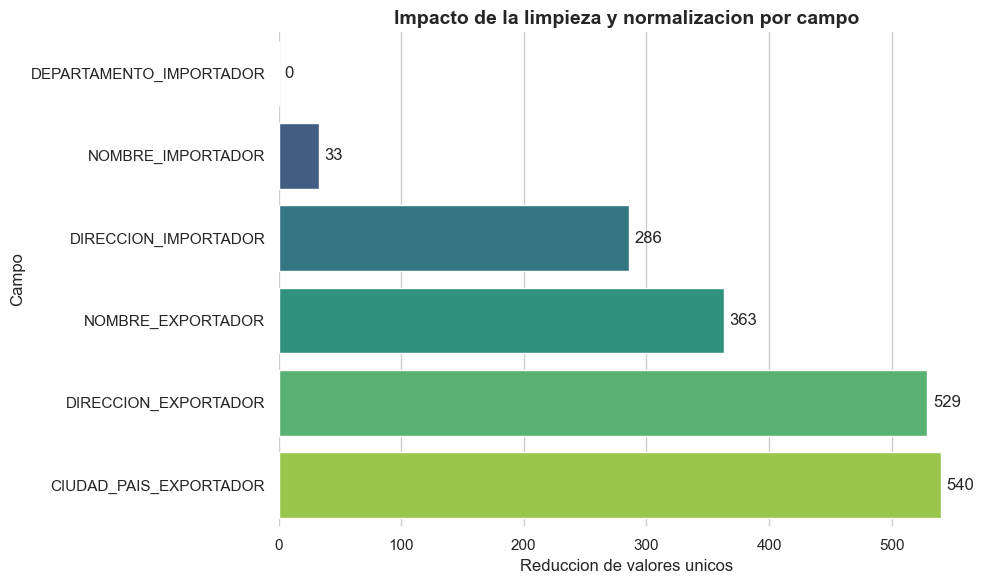

,campo,tipo_normalizacion,total_registros,nulos,porcentaje_nulos,vacios,porcentaje_vacios,con_tildes,porcentaje_con_tildes,con_ñ,porcentaje_con_ñ,con_espacios_extra,porcentaje_espacios_extra,con_caracteres_raros,porcentaje_caracteres_raros,valores_unicos_originales,valores_unicos_normalizados,reduccion_unicos_por_normalizacion,porcentaje_reduccion_unicos
0,NOMBRE_IMPORTADOR,"General: mayúsculas, tildes y espacios",201855,0,0,0,0,0,0,0,0,15770,8,7539,4,10923,10890,33,0
1,NOMBRE_EXPORTADOR,"General: mayúsculas, tildes y espacios",201855,0,0,0,0,0,0,0,0,2610,1,17316,9,25455,25092,363,1
2,CIUDAD_PAIS_EXPORTADOR,"General: mayúsculas, tildes y espacios",201855,202,0,0,0,0,0,0,0,1335,1,625,0,8531,7991,540,6
3,DEPARTAMENTO_IMPORTADOR,"General: mayúsculas, tildes y espacios",201855,0,0,0,0,0,0,639,0,0,0,0,0,31,31,0,0
4,DIRECCION_IMPORTADOR,Dirección: mayúsculas y espacios,201855,2229,1,0,0,1,0,70,0,176919,88,2210,1,11036,10750,286,3
5,DIRECCION_EXPORTADOR,Dirección: mayúsculas y espacios,201855,191,0,0,0,3440,2,788,0,2390,1,6537,3,28618,28089,529,2


In [353]:
# 4. Crear visualizaciones
create_visualizations(df, entity_stats)

## Interpretación
La limpieza y normalización tuvo mayor impacto en ciudad_pais_exportador, con una reducción de 540 valores únicos, seguido de direccion_exportador, con 529 valores únicos menos, y nombre_exportador, con una reducción de 363. Esto indica que las principales variaciones de escritura se concentran en la información del exportador y su ubicación, probablemente por diferencias en tildes, espacios, mayúsculas/minúsculas y formatos de captura.

In [198]:
pattern_stats["resumen_general"]

,metrica,valor
0,total_filas,201855
1,total_columnas,125
2,filas_duplicadas,0


In [199]:
pattern_stats["resumen_numericas"].query("negativos > 0")

,columna,tipo_dato,nulos,valores_unicos,minimo,maximo,negativos,ceros,requiere_revision
31,VALOR_AJUSTE_USD,float64,0,2469,-2039761,1872674,2029,199135,Sí
40,BASE_ARANCEL,int64,0,180565,-1161740,131201108885,1,24,Sí
43,BASE_IVA,int64,0,191043,-1161740,131201108885,1,2,Sí


In [200]:
columnas_revision = [
    "MANIFIESTO_CARGA",
    "NOMBRE_IMPORTADOR",
    "NOMBRE_EXPORTADOR",
    "BASE_ARANCEL",
    "BASE_IVA",
    "VALOR_AJUSTE_USD"
]

columnas_revision = [col for col in columnas_revision if col in df.columns]

df[
    (df["BASE_ARANCEL"] < 0) | 
    (df["BASE_IVA"] < 0)
][columnas_revision]

,NOMBRE_IMPORTADOR,NOMBRE_EXPORTADOR,BASE_ARANCEL,BASE_IVA,VALOR_AJUSTE_USD
26697,C.I PRODUCTORA INTERNACIONAL DE GRASAS SAS,ADIPLUS S.A.C,-1161740,-1161740,-309


In [204]:
df_normalizado['EMPRESA_TRANSPORTADORA']

0                             SKY LOGISTICA INTEGRAL SAS
1         AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA
2         AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA
3         AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA
4            FRONTIER AGENCIA MARITIMA DEL CARIBE S.A.S.
                               ...                      
201850                        HAPAG LLOYD COLOMBIA LTDA.
201851                         FRONTIER AGENCIA MARITIMA
201852                         FRONTIER AGENCIA MARITIMA
201853                               MAERSK COLOMBIA S.A
201854                         FRONTIER AGENCIA MARITIMA
Name: EMPRESA_TRANSPORTADORA, Length: 201855, dtype: object

## Analisis inicial:
En primer lugar, se realizó un diagnóstico de calidad sobre los campos asociados a entidades, ubicaciones y direcciones. Para las columnas de texto se aplicó una normalización general que consistió en convertir los valores a mayúsculas, eliminar tildes en vocales, conservar la letra Ñ, reducir espacios múltiples y transformar valores vacíos en nulos cuando correspondía. En el caso de las direcciones, se aplicó una normalización más conservadora, limitada a mayúsculas y limpieza de espacios, con el fin de no alterar elementos estructurales como guiones, numeración o caracteres propios de la dirección. 

Adicionalmente, se revisó la completitud de los campos principales. Los porcentajes de valores nulos identificados fueron bajos en relación con el total de registros, por lo que no se consideró necesario aplicar técnicas de imputación. En lugar de modificar la información faltante, se optó por conservar los nulos.

En términos generales, no se encontraron filas completamente duplicadas. En cuanto a las variables numéricas, se identificaron valores negativos en tres columnas: `valor_ajuste_usd`, `base_arancel` y `base_iva`. El caso más relevante corresponde a un registro donde `base_arancel` y `base_iva` presentan simultáneamente el valor de -116.740, acompañado de un `valor_ajuste_usd` negativo. Este registro se clasificó como una anomalía para revisión, pero no se modificó automáticamente. Dado que se trata de un único registro, su impacto sobre los resultados generales de la base es bajo. Sin embargo, debe conservarse marcado para validación con reglas de negocio o con la fuente original.


### **Bloque 2: Desarrollo de Algoritmo de Matching**

Desarrolla un algoritmo que pueda identificar cuando dos nombres de empresa se refieren
a la misma entidad, considerando:
- Variaciones en el orden de las palabras
- Errores tipográficos comunes
- Abreviaciones y acrónimos
- Diferentes formatos legales (S.A., LTDA, etc.)

Requerimientos:
1. Implementa al menos dos métodos diferentes de matching
2. Evalúa y compara su efectividad
3. Propón una métrica para medir la calidad del matching
4. Documenta los casos edge que identificaste

## Introducción
Después del análisis exploratorio y la normalización inicial de los campos de entidades, se desarrolló un algoritmo para identificar posibles nombres de empresa que podrían referirse a una misma entidad. El análisis se enfocó en la columna empresa_transportadora, utilizando la versión normalizada del nombre de empresa. Esta normalización permitió reducir diferencias generadas por mayúsculas/minúsculas, tildes, puntuación, espacios adicionales, abreviaciones y distintos formatos legales como s.a., s.a.s. o ltda.

In [9]:
def normalize_company_name(name):
    """
    Implementa la normalización básica de nombres de empresas.
    """
    # Tu código aquí
    pass

In [280]:
def normalize_company_name(name):
    """
    Normaliza nombres de empresas sin eliminar formatos legales comunes.
    """
    if pd.isna(name):
        return ""

    name = str(name).upper().strip()

    # Quitar tildes
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))

    # Quitar signos y caracteres especiales
    name = re.sub(r"[^A-Z0-9\s]", " ", name)

    # Normalizar espacios
    name = re.sub(r"\s+", " ", name).strip()

    return name

## Fuzzy 
Para el desarrollo del algoritmo se implementaron dos métodos de matching. El primero fue Token sort match, que compara los nombres después de ordenar alfabéticamente sus palabras. Este método es útil para identificar coincidencias cuando el orden de los términos cambia, por ejemplo, entre “TRANSPORTES BOGOTA SAS” y “BOGOTA TRANSPORTES SAS”. 


In [290]:
def match_companies_fuzzy(name1, name2, threshold=85):
    """
    Compara dos nombres de empresa usando fuzzy matching.
    """
    n1 = normalize_company_name(name1)
    n2 = normalize_company_name(name2)

    score_token_sort = fuzz.token_sort_ratio(n1, n2)
    score_token_set = fuzz.token_set_ratio(n1, n2)

    score = max(score_token_sort, score_token_set)

    return {
        "name1_norm": n1,
        "name2_norm": n2,
        "fuzzy_score": score,
        "fuzzy_match": score >= threshold
    }

## Similutd del coseno
El segundo método fue TF-IDF y similitud coseno, basado en n-gramas de caracteres, el cual permite capturar similitudes parciales entre nombres y es útil frente a errores de escritura o abreviaciones. 

In [289]:
def match_companies_cosine(name1, name2, threshold=0.85):
    """
    Compara dos nombres de empresa usando similitud del coseno
    sobre vectores TF-IDF de caracteres.
    """
    n1 = normalize_company_name(name1)
    n2 = normalize_company_name(name2)

    vectorizer = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5)
    )

    tfidf_matrix = vectorizer.fit_transform([n1, n2])

    score = cosine_similarity(
        tfidf_matrix[0],
        tfidf_matrix[1]
    )[0][0]

    return {
        "name1_norm": n1,
        "name2_norm": n2,
        "cosine_score": score,
        "match": score >= threshold
    }

In [291]:
def match_companies(name1, name2, threshold=85):
    """
    Compara dos nombres de empresa usando fuzzy matching y similitud del coseno.
    """
    fuzzy_result = match_companies_fuzzy(name1, name2, threshold)

    cosine_result = match_companies_cosine(
        name1,
        name2,
        threshold=threshold / 100
    )

    return {
        **fuzzy_result,
        "cosine_score": cosine_result["cosine_score"] * 100,
        "cosine_match": cosine_result["match"],
        "best_score": max(
            fuzzy_result["fuzzy_score"],
            cosine_result["cosine_score"] * 100
        ),
        "final_match": (
            fuzzy_result["fuzzy_match"] or
            cosine_result["match"]
        )
    }

In [292]:
empresas_unicas = (
    df_normalizado["EMPRESA_TRANSPORTADORA"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

resultados = []

for i in range(len(empresas_unicas)):
    for j in range(i + 1, len(empresas_unicas)):
        resultado = match_companies(
            empresas_unicas[i],
            empresas_unicas[j],
            threshold=85
        )

        resultados.append({
            "empresa_1": empresas_unicas[i],
            "empresa_2": empresas_unicas[j],
            "fuzzy_score": resultado["fuzzy_score"],
            "fuzzy_match": resultado["fuzzy_match"],
            "cosine_score": resultado["cosine_score"],
            "cosine_match": resultado["cosine_match"],
            "best_score": resultado["best_score"],
            "final_match": resultado["final_match"]
        })

df_comparacion = pd.DataFrame(resultados)
df_comparacion.head()

,empresa_1,empresa_2,fuzzy_score,fuzzy_match,cosine_score,cosine_match,best_score,final_match
0,SKY LOGISTICA INTEGRAL SAS,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,34,False,3,False,34,False
1,SKY LOGISTICA INTEGRAL SAS,FRONTIER AGENCIA MARITIMA DEL CARIBE S.A.S.,41,False,0,False,41,False
2,SKY LOGISTICA INTEGRAL SAS,EMPRESA COLOMBIANA DE LOGISTICA SAS,67,False,29,False,67,False
3,SKY LOGISTICA INTEGRAL SAS,UNITED PARCEL SERVICE CO SUCURSAL COLOMBIA,32,False,1,False,32,False
4,SKY LOGISTICA INTEGRAL SAS,IBERIA,31,False,0,False,31,False


In [293]:
df_comparacion.head(50)

,empresa_1,empresa_2,fuzzy_score,fuzzy_match,cosine_score,cosine_match,best_score,final_match
0,SKY LOGISTICA INTEGRAL SAS,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,34,False,3,False,34,False
1,SKY LOGISTICA INTEGRAL SAS,FRONTIER AGENCIA MARITIMA DEL CARIBE S.A.S.,41,False,0,False,41,False
2,SKY LOGISTICA INTEGRAL SAS,EMPRESA COLOMBIANA DE LOGISTICA SAS,67,False,29,False,67,False
3,SKY LOGISTICA INTEGRAL SAS,UNITED PARCEL SERVICE CO SUCURSAL COLOMBIA,32,False,1,False,32,False
4,SKY LOGISTICA INTEGRAL SAS,IBERIA,31,False,0,False,31,False
5,SKY LOGISTICA INTEGRAL SAS,DHL AERO EXPRESO S A SUCURSAL COLOMBIA,38,False,1,False,38,False
6,SKY LOGISTICA INTEGRAL SAS,DHL EXPRESS COLOMBIA LTDA.,31,False,0,False,31,False
7,SKY LOGISTICA INTEGRAL SAS,SEABOARD DE COLOMBIA S.A.,40,False,0,False,40,False
8,SKY LOGISTICA INTEGRAL SAS,AGENCIA OCEANICA OCEANIC LTDA.,33,False,2,False,33,False
9,SKY LOGISTICA INTEGRAL SAS,ATLAS AIR INC SUCURSAL COLOMBIA,46,False,3,False,46,False


In [294]:
resumen_metodos = pd.DataFrame({
    "metodo": ["Fuzzy matching", "Similitud del coseno"],
    "matches_detectados": [
        df_comparacion["fuzzy_match"].sum(),
        df_comparacion["cosine_match"].sum()
    ],
    "score_promedio": [
        df_comparacion["fuzzy_score"].mean(),
        df_comparacion["cosine_score"].mean()
    ],
    "score_maximo": [
        df_comparacion["fuzzy_score"].max(),
        df_comparacion["cosine_score"].max()
    ]
})

resumen_metodos

,metodo,matches_detectados,score_promedio,score_maximo
0,Fuzzy matching,502,43,100
1,Similitud del coseno,93,7,100


In [295]:
df_comparacion["calidad_matching"] = pd.cut(
    df_comparacion["best_score"],
    bins=[0, 70, 85, 95, 100],
    labels=["Baja", "Media", "Alta", "Muy alta"],
    include_lowest=True
)

df_comparacion[
    df_comparacion["final_match"]
].sort_values("best_score", ascending=False)

,empresa_1,empresa_2,fuzzy_score,fuzzy_match,cosine_score,cosine_match,best_score,final_match,calidad_matching
66685,AEROVIAS DE INTEGRACION REGIONAL S.A AIRES,AEROVIAS DE INTEGRACION REGIONAL S.A. AIRES,100,True,100,True,100,True,NaN
48007,KLM CIA REAL HOLANDESA DE AVIACION,KLM CIA. REAL HOLANDESA DE AVIACION,100,True,100,True,100,True,NaN
75929,TRANSPORTES SARVI LTDA VENCIDO-,TRANSPORTES SARVI LTDA VENCIDO -,100,True,100,True,100,True,NaN
13384,KLM CIA. REAL HOLANDESA DE AVIACION.,KLM CIA REAL HOLANDESA DE AVIACION,100,True,100,True,100,True,NaN
13609,KLM CIA. REAL HOLANDESA DE AVIACION.,KLM CIA. REAL HOLANDESA DE AVIACION,100,True,100,True,100,True,NaN
...,...,...,...,...,...,...,...,...,...
23137,LBH COLOMBIA S.A.S,CARGA Y LOGISTICA DE COLOMBIA S.A.,86,True,39,False,86,True,Alta
18869,AIR CANADA SUCURSAL COLOMBIA,UNITED AIR LINES INC SUCURSAL COLOMBIA,86,True,51,False,86,True,Alta
18931,AIR CANADA SUCURSAL COLOMBIA,LATAM AIR LINE PERU S.A. SUCURSAL COLOMBIA,86,True,52,False,86,True,Alta
6436,MEDITERRANEAN SHIPPING COMPANY COLOMBIA S.A.,LBH COLOMBIA S.A.S,86,True,31,False,86,True,Alta


Al evaluar los métodos de matching se identificó que el tiempo de ejecución puede ser alto, debido a que el enfoque inicial compara cada empresa contra todas las demás empresas. Esta estrategia genera un crecimiento cuadratico en el número de comparaciones, por lo que no es eficiente cuando aumenta la cantidad de nombres únicos.

Por esta razón, se propone implementar una estrategia de blocking, que consiste en agrupar previamente las empresas a partir de tokens o palabras relevantes del nombre normalizado. De esta manera, el algoritmo solo compara empresas que comparten algún bloque común, evitando comparaciones innecesarias entre nombres que no tienen una probabilidad razonable de corresponder a la misma entidad.


### **Bloque 3: Escalabilidad y Optimización (Opcional)**

Ahora que has desarrollado un algoritmo básico, necesitamos escalarlo para procesar
grandes volúmenes de datos eficientemente.

### Tareas:
1. Optimiza tu algoritmo para mejorar su rendimiento
2. Implementa una estrategia para reducir comparaciones innecesarias
3. Propón una estructura de datos eficiente para almacenar los matches
4. Sugiere una arquitectura para procesar actualizaciones incrementales

## Implementación

Para la construcción de los bloques no se tuvieron en cuenta palabras demasiado generales del dominio, como “transportes”, “transportadora”, “transportador”, “logística”, “carga” o términos legales como “s.a.”, “s.a.s.” y “ltda.” cabe aclarar que estas palabras no se eliminaron del nombre normalizado final, sino que solo se ignoraron para construir la clave de bloqueo. Estas palabras aparecen con alta frecuencia en empresas del sector transporte y, por sí solas, no permiten diferenciar adecuadamente una entidad de otra. Por tanto, se priorizaron tokens más informativos del nombre de la empresa, con el fin de reducir falsos positivos y mejorar la eficiencia del proceso de comparación.

In [354]:
def get_blocking_key(name):
    """
    Reducir comparaciones innecesarias.
    """
    name_norm = normalize_company_name(name)
    words = name_norm.split()

    if len(words) == 0:
        return ""


    common_words = {
        "TRANSPORTES", "TRANSPORTADORA", "TRANS",
        "LOGISTICA", "CARGA", "SERVICIOS"
    }

    important_words = [
        w for w in words
        if w not in common_words
    ]

    if len(important_words) == 0:
        important_words = words

    # Usamos la primera palabra importante y sus primeras 4 letras
    return important_words[0][:4]

In [302]:
def find_matches_blocking(df, column="EMPRESA_TRANSPORTADORA", threshold=85):
    empresas = (
        df[column]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    df_empresas = pd.DataFrame({
        "empresa": empresas
    })

    df_empresas["empresa_norm"] = df_empresas["empresa"].apply(normalize_company_name)
    df_empresas["blocking_key"] = df_empresas["empresa"].apply(get_blocking_key)

    matches = []

    for blocking_key, grupo in df_empresas.groupby("blocking_key"):
        empresas_grupo = grupo["empresa"].tolist()

        for i in range(len(empresas_grupo)):
            for j in range(i + 1, len(empresas_grupo)):
                resultado = match_companies(
                    empresas_grupo[i],
                    empresas_grupo[j],
                    threshold=threshold
                )

                matches.append({
                    "blocking_key": blocking_key,
                    "empresa_1": empresas_grupo[i],
                    "empresa_2": empresas_grupo[j],
                    "fuzzy_score": resultado["fuzzy_score"],
                    "fuzzy_match": resultado["fuzzy_match"],
                    "cosine_score": resultado["cosine_score"],
                    "cosine_match": resultado["cosine_match"],
                    "best_score": resultado["best_score"],
                    "final_match": resultado["final_match"]
                })

    return pd.DataFrame(matches)

In [303]:
df_matches_blocking = find_matches_blocking(
    df_normalizado,
    column="EMPRESA_TRANSPORTADORA",
    threshold=85
)

df_matches_blocking.sort_values("best_score", ascending=False)

,blocking_key,empresa_1,empresa_2,fuzzy_score,fuzzy_match,cosine_score,cosine_match,best_score,final_match
96,AERO,AEROVIAS DE INTEGRACION REGIONAL S.A AIRES,AEROVIAS DE INTEGRACION REGIONAL S.A. AIRES,100,True,100,True,100,True
712,SARV,TRANSPORTES SARVI LTDA VENCIDO-,TRANSPORTES SARVI LTDA VENCIDO -,100,True,100,True,100,True
537,KLM,KLM CIA. REAL HOLANDESA DE AVIACION.,KLM CIA. REAL HOLANDESA DE AVIACION,100,True,100,True,100,True
538,KLM,KLM CIA REAL HOLANDESA DE AVIACION,KLM CIA. REAL HOLANDESA DE AVIACION,100,True,100,True,100,True
536,KLM,KLM CIA. REAL HOLANDESA DE AVIACION.,KLM CIA REAL HOLANDESA DE AVIACION,100,True,100,True,100,True
...,...,...,...,...,...,...,...,...,...
871,TRAN,TRANSOCEANOS E.U.,TRANSPORTE DE CARGA NACIONAL E INTERNACIONAL N...,29,False,7,False,29,False
982,TRAN,TRANSBISAM S.A,TRANSPORTE Y COMERCIO INTERNACIONAL LIMITADA,28,False,9,False,28,False
954,TRAN,TRANSPORTE DE CARGA NACIONAL E INTERNACIONAL A...,TRANSBISAM S.A,27,False,8,False,27,False
899,TRAN,TRANSPORTE Y COMERCIO INTERNACIONAL TRANSCOMER...,TRANSBISAM S.A,27,False,14,False,27,False


En la tabla se presentan los pares de empresas comparados dentro de cada bloque, junto con el puntaje obtenido por cada método de matching. El campo fuzzy_score corresponde a la similitud textual directa entre los nombres, mientras que cosine_score corresponde a la similitud calculada mediante TF-IDF y coseno. Para tomar la decisión final, se utiliza el mayor puntaje entre ambos métodos, registrado en best_score, y se clasifica como posible coincidencia cuando dicho puntaje supera el umbral definido. Esta decisión queda reflejada en la columna final_match.

La tabla también permite identificar casos en los que un método detecta la coincidencia y el otro no. Por ejemplo, algunos pares pueden tener un puntaje alto en fuzzy_score, pero bajo en cosine_score, lo que indica que la coincidencia depende más de la similitud global del texto que de la similitud basada en n-gramas.


In [305]:
def count_blocking_comparisons(df, column="EMPRESA_TRANSPORTADORA"):
    empresas = (
        df[column]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    total_empresas = len(empresas)
    comparaciones_todos_contra_todos = total_empresas * (total_empresas - 1) // 2

    df_empresas = pd.DataFrame({"empresa": empresas})
    df_empresas["blocking_key"] = df_empresas["empresa"].apply(get_blocking_key)

    comparaciones_blocking = 0

    for _, grupo in df_empresas.groupby("blocking_key"):
        n = len(grupo)
        comparaciones_blocking += n * (n - 1) // 2

    reduccion = 1 - (comparaciones_blocking / comparaciones_todos_contra_todos)

    return {
        "empresas_unicas": total_empresas,
        "comparaciones_todos_contra_todos": comparaciones_todos_contra_todos,
        "comparaciones_con_blocking": comparaciones_blocking,
        "reduccion_porcentual": reduccion * 100
    }

In [306]:
count_blocking_comparisons(df_normalizado)

{'empresas_unicas': 408,
 'comparaciones_todos_contra_todos': 83028,
 'comparaciones_con_blocking': 1352,
 'reduccion_porcentual': 98.37163366575132}

## EJERCICIO BONUS: INTEGRACIÓN CON LLMs

Demuestra cómo podrías mejorar la solución anterior utilizando Large Language Models (LLMs).
Específicamente, integra Groq (https://groq.com/) y otros modelos open source como Llama.

#### Objetivos:
1. Uso de LLMs para mejorar el matching y normalización
2. Implementación eficiente y costos-efectiva
3. Manejo de casos edge con ayuda de LLMs

##### Tareas:
1. Implementa un pipeline que utilice Groq API para:
   - Normalización de nombres de empresas
   - Detección de entidades similares
   - Validación de matches dudosos

2. Compara el rendimiento y precisión entre:
   - Tu solución basada en reglas/algoritmos
   - Solución utilizando LLMs
   - Enfoque híbrido

3. Optimización de costos:
   - Estrategia para minimizar llamadas a la API
   - Caching inteligente de resultados
   - Balance entre precisión y costos

4. Casos de uso avanzados:
   - Extracción de información adicional de las descripciones
   - Categorización automática de empresas
   - Detección de anomalías en los datos

## Propuesta hibrida 

Aunque las técnicas de matching implementadas permiten identificar una parte importante de las coincidencias entre nombres de empresas, todavía existen casos ambiguos en los que la decisión no debería tomarse únicamente con base en un puntaje numérico.

Esta parte propone un pipeline híbrido. Primero, se usan métodos clásicos de matching para reducir el conjunto de empresas a comparar, luego, se aplica blocking para mejorar la eficiencia del proceso; y finalmente, se plantea el uso de LLMs como apoyo para revisar los casos ambiguos que requieren interpretación semántica adicional.


In [313]:
from groq import Groq
from dotenv import load_dotenv
import hashlib
import os
load_dotenv()
client = Groq(
    api_key=os.environ.get("GROQ_API_KEY"),
)

In [324]:
def normalize_entity_with_llm(entity_name, client):
    """
    Utiliza Groq para normalizar nombres de entidades.
    """
    prompt = f"""
    Normaliza el siguiente nombre de empresa, eliminando variaciones innecesarias 
    y manteniendo la información esencial: {entity_name}
    
    Formato deseado:
    - Sin puntuación innecesaria
    - Siglas de forma estándar
    - Tipo de empresa al final (SA, LTDA, etc.)
    """
    
    try:
        response = client.chat.completions.create(
            model="mixtral-8x7b-32768",
            messages=[
                {"role": "system", "content": "Eres un experto en normalización de nombres de empresas."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Error al llamar a Groq API: {e}")
        return entity_name

In [334]:
def match_entities_with_llm(entity1, entity2, client):
    """
    Utiliza Groq para determinar si dos entidades son la misma
    """
    prompt = f"""
    Determina si las siguientes dos empresas son la misma entidad:
    Empresa 1: {entity1}
    Empresa 2: {entity2}
    
    Responde con:
    - MATCH: Si son definitivamente la misma empresa
    - POSSIBLE_MATCH: Si probablemente son la misma empresa
    - NO_MATCH: Si son empresas diferentes
    
    Explica tu razonamiento.
    """
    
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": "Eres un experto en identificación y matching de entidades empresariales."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Error al llamar a Groq API: {e}")
        return "ERROR"

In [336]:
def get_cache_key(*values):
    text = "||".join(str(v).upper().strip() for v in values)
    return hashlib.md5(text.encode("utf-8")).hexdigest()

In [337]:
def normalize_entity_with_llm_cached(entity_name, client):
    key = get_cache_key(entity_name)

    if key not in llm_normalization_cache:
        llm_normalization_cache[key] = normalize_entity_with_llm(
            entity_name,
            client
        )

    return llm_normalization_cache[key]

In [338]:
def match_entities_with_llm_cached(entity1, entity2, client):
    # Ordenamos para que A-B y B-A usen la misma clave
    pair = sorted([str(entity1), str(entity2)])
    key = get_cache_key(pair[0], pair[1])

    if key not in llm_match_cache:
        llm_match_cache[key] = match_entities_with_llm(
            pair[0],
            pair[1],
            client
        )

    return llm_match_cache[key]

In [339]:
def classify_match_for_llm(resultado, low_threshold=70, high_threshold=92):
    """
    Decide si un match se resuelve automáticamente o si debe ir al LLM.
    """
    score = resultado["best_score"]

    if score >= high_threshold:
        return "AUTO_MATCH"

    if score < low_threshold:
        return "AUTO_NO_MATCH"

    return "LLM_REVIEW"

In [340]:
def hybrid_match_companies(name1, name2, client, low_threshold=70, high_threshold=92):
    """
    Combina reglas, fuzzy matching, similitud del coseno y LLM.
    """
    algorithm_result = match_companies(
        name1,
        name2,
        threshold=85
    )

    decision_type = classify_match_for_llm(
        algorithm_result,
        low_threshold=low_threshold,
        high_threshold=high_threshold
    )

    if decision_type == "AUTO_MATCH":
        llm_result = None
        final_decision = "MATCH"

    elif decision_type == "AUTO_NO_MATCH":
        llm_result = None
        final_decision = "NO_MATCH"

    else:
        llm_result = match_entities_with_llm_cached(
            name1,
            name2,
            client
        )

        if "MATCH" in llm_result and "NO_MATCH" not in llm_result:
            final_decision = "MATCH"
        elif "POSSIBLE_MATCH" in llm_result:
            final_decision = "POSSIBLE_MATCH"
        elif "NO_MATCH" in llm_result:
            final_decision = "NO_MATCH"
        else:
            final_decision = "REVIEW_MANUAL"

    return {
        "empresa_1": name1,
        "empresa_2": name2,
        "fuzzy_score": algorithm_result["fuzzy_score"],
        "cosine_score": algorithm_result["cosine_score"],
        "best_score": algorithm_result["best_score"],
        "algorithm_match": algorithm_result["final_match"],
        "decision_type": decision_type,
        "llm_result": llm_result,
        "final_decision": final_decision
    }

In [341]:
def apply_hybrid_pipeline(df_matches_blocking, client):
    resultados = []

    for _, row in df_matches_blocking.iterrows():
        resultado = hybrid_match_companies(
            row["empresa_1"],
            row["empresa_2"],
            client
        )

        resultados.append(resultado)

    return pd.DataFrame(resultados)

In [342]:
df_hybrid_results = apply_hybrid_pipeline(
    df_matches_blocking,
    client
)

df_hybrid_results.head()

Error al llamar a Groq API: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krg0av55env8zwz75pcj09yg` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99587, Requested 564. Please try again in 2m10.464s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Error al llamar a Groq API: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krg0av55env8zwz75pcj09yg` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99587, Requested 524. Please try again in 1m35.904s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
Error al llamar a Groq API: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in o

,empresa_1,empresa_2,fuzzy_score,cosine_score,best_score,algorithm_match,decision_type,llm_result,final_decision
0,ABSA AEROLINEAS BRASILEIRAS S.A.FILIAL COLOMBIA,ABSA AEROLINEAS BRASILIERAS FILIAL COLOMBIA,93,75,93,True,AUTO_MATCH,None,MATCH
1,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROSUCRE S.A.,38,9,38,False,AUTO_NO_MATCH,None,NO_MATCH
2,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA...,100,99,100,True,AUTO_MATCH,None,MATCH
3,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROSUCRE S.A. CABOTAJE,48,6,48,False,AUTO_NO_MATCH,None,NO_MATCH
4,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROLINEA DEL CARIBE S.A.,58,13,58,False,AUTO_NO_MATCH,None,NO_MATCH


In [348]:
metricas_hibrido = {
    "total_pares_evaluados": len(df_hybrid_results),
    "pares_resueltos_automaticamente": (
        df_hybrid_results["decision_type"] != "LLM_REVIEW"
    ).sum(),
    "pares_enviados_a_llm": (
        df_hybrid_results["decision_type"] == "LLM_REVIEW"
    ).sum(),
    "porcentaje_llamadas_llm": (
        (df_hybrid_results["decision_type"] == "LLM_REVIEW").mean() * 100
    ),
    "matches_finales": (
        df_hybrid_results["final_decision"] == "MATCH"
    ).sum(),
    "posibles_matches": (
        df_hybrid_results["final_decision"] == "POSSIBLE_MATCH"
    ).sum(),
    "no_matches": (
        df_hybrid_results["final_decision"] == "NO_MATCH"
    ).sum()
}

metricas_hibrido

{'total_pares_evaluados': 1352,
 'pares_resueltos_automaticamente': np.int64(1056),
 'pares_enviados_a_llm': np.int64(296),
 'porcentaje_llamadas_llm': np.float64(21.893491124260358),
 'matches_finales': np.int64(339),
 'posibles_matches': np.int64(0),
 'no_matches': np.int64(934)}

In [355]:
df_hybrid_results.head(20)

,empresa_1,empresa_2,fuzzy_score,cosine_score,best_score,algorithm_match,decision_type,llm_result,final_decision
0,ABSA AEROLINEAS BRASILEIRAS S.A.FILIAL COLOMBIA,ABSA AEROLINEAS BRASILIERAS FILIAL COLOMBIA,93,75,93,True,AUTO_MATCH,None,MATCH
1,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROSUCRE S.A.,38,9,38,False,AUTO_NO_MATCH,None,NO_MATCH
2,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA...,100,99,100,True,AUTO_MATCH,None,MATCH
3,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROSUCRE S.A. CABOTAJE,48,6,48,False,AUTO_NO_MATCH,None,NO_MATCH
4,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROLINEA DEL CARIBE S.A.,58,13,58,False,AUTO_NO_MATCH,None,NO_MATCH
5,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DE MEXICO S.A DE C.V AEROMEXICO SUCUR...,58,16,58,False,AUTO_NO_MATCH,None,NO_MATCH
6,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DEL CONTINENTE AMERICANO SA-AVIANCA SA,97,88,97,True,AUTO_MATCH,None,MATCH
7,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DE INTEGRACION REGIONAL S.A. AIRES S.A.,57,17,57,False,AUTO_NO_MATCH,None,NO_MATCH
8,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROVIAS DE INTEGRACION REGIONAL S.A AIRES,57,16,57,False,AUTO_NO_MATCH,None,NO_MATCH
9,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA,AEROENLACES NACIONALES SA DE CV SUCURSAL COLOMBIA,45,4,45,False,AUTO_NO_MATCH,None,NO_MATCH


En el código se parte de la tabla de resultados del matching, donde cada par de empresas tiene asociados puntajes como fuzzy_score, cosine_score, best_score y la decisión preliminar final_match. A partir de estos resultados, se pueden seleccionar los pares que requieren una revisión más cuidadosa, por ejemplo, aquellos que tienen puntajes cercanos al umbral de decisión o aquellos donde un método indica coincidencia y el otro no. 

## Resultados

El enfoque híbrido permitió combinar eficiencia y precisión. El algoritmo basado en reglas, fuzzy matching y similitud del coseno resolvió automáticamente la mayoría de los casos. El LLM se utilizó únicamente como una capa de validación para pares ambiguos, reduciendo costos y evitando llamadas innecesarias a la API. La estrategia es costo-efectiva porque no se envían al LLM las 83.028 (combinaciones de 408 elementos tomados de 2 en 2) comparaciones posibles, sino únicamente 296 pares en duda. Esto equivale a usar LLMs sobre apenas el 0,36% de las comparaciones que habría requerido el enfoque todos contra todos.

